In [31]:
import pandas as pd
import sqlalchemy as sa

In [32]:
server = "127.0.0.1,1500"
database = "DEP2"
username = "sa"
password = "dep2025-G12"
driver = "ODBC Driver 17 for SQL Server"

engine = sa.create_engine(
    f"mssql+pyodbc://{username}:{password}@{server}/{database}?driver={driver}"
)

with engine.connect() as conn:
    query = """SELECT *
    FROM FactLecture
    JOIN DimDate ON FactLecture.DateKey = DimDate.DateKey
    JOIN DimTime dt_from ON FactLecture.FromTimeKey = dt_from.TimeKey
    JOIN DimTime dt_until ON FactLecture.UntilTimeKey = dt_until.TimeKey
    JOIN DimClass ON FactLecture.ClassKey = DimClass.ClassKey
    JOIN DimSubgroup ON FactLecture.SubgroupKey = DimSubgroup.SubgroupKey
    JOIN DimActivity ON FactLecture.ActivityKey = DimActivity.ActivityKey
    WHERE FactLecture.DateKey < CONVERT(VARCHAR, GETDATE(), 112) AND AttendanceRate IS NOT NULL""" # Only lectures before today
    df_fact_lecture = pd.read_sql(query, conn)

df_fact_lecture

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent
0,398529,20251105,104500,124500,4693,5722796,1555,7,0,14,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
1,458372,20251120,81500,123000,4692,5722805,1113,2,7,12,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
2,468315,20251209,91500,130000,6400,5722831,1539,9,5,33,...,False,False,False,False,True,False,False,2025-11-04 19:38:40.001994,None,True
3,468317,20251209,130000,153000,6400,5722831,1614,9,1,33,...,False,False,False,False,True,False,False,2025-11-04 19:38:40.001994,None,True
4,468308,20251204,91500,123000,6400,5722831,1120,9,2,33,...,False,False,False,False,True,False,False,2025-11-04 19:38:40.001994,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6601,470796,20251119,103000,123000,10867,6160650,1105,2,3,24,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6602,397816,20251119,81500,101500,10867,6160650,1105,2,7,24,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6603,397821,20251126,81500,101500,10867,6160650,1122,2,1,24,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6604,470797,20251126,103000,123000,10867,6160650,1108,2,0,24,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True


In [33]:
# Drop repeat columns
df = df_fact_lecture.copy()
df = df.loc[:, ~df.columns.duplicated()]
df.columns

Index(['LectureID', 'DateKey', 'FromTimeKey', 'UntilTimeKey', 'ClassKey',
       'SubgroupKey', 'RoomKey', 'ActivityKey', 'UserCount', 'TotalStudents',
       'AttendanceRate', 'OccupancyRate', 'FullDate', 'NameDay',
       'NameMonthDutch', 'NameMonthEN', 'NameDayDutch', 'NameDayEN',
       'NameQuarter', 'NumberQuarter', 'NumberSemester', 'Month', 'Year',
       'Weekday', 'DayOfYear', 'Season', 'TimeKey', 'Hour', 'Minutes',
       'Seconds', 'FullTime', 'TimeAM_PM', 'ClassName', 'ClassCode',
       'ClassCredits', 'ClassSecondChance', 'ClassProgramStage',
       'SubgroupCode', 'ProgramName', 'CanonicalActivity', 'ActivityDomain',
       'ActivityGroup', 'SourceColumn', 'SourceValue', 'IsCourse', 'IsExam',
       'IsAcademicEvent', 'IsGuestLecture', 'IsMakeUp', 'IsPractical',
       'IsPresentation', 'IsDigitalPossible', 'ValidFrom', 'ValidTo',
       'IsCurrent'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6606 entries, 0 to 6605
Data columns (total 55 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LectureID          6606 non-null   int64         
 1   DateKey            6606 non-null   int64         
 2   FromTimeKey        6606 non-null   int64         
 3   UntilTimeKey       6606 non-null   int64         
 4   ClassKey           6606 non-null   int64         
 5   SubgroupKey        6606 non-null   int64         
 6   RoomKey            6606 non-null   int64         
 7   ActivityKey        6606 non-null   int64         
 8   UserCount          6606 non-null   int64         
 9   TotalStudents      6606 non-null   int64         
 10  AttendanceRate     6606 non-null   float64       
 11  OccupancyRate      6606 non-null   float64       
 12  FullDate           6606 non-null   object        
 13  NameDay            6606 non-null   object        
 14  NameMont

In [35]:
df = df.sort_values(["ClassKey", "DateKey", "FromTimeKey"]).reset_index(drop=True)
df

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent
0,422331,20251002,180000,200000,17,5876654,1118,2,28,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
1,422332,20251009,180000,200000,17,5876654,1580,2,22,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
2,422333,20251016,180000,200000,17,5876654,1607,2,27,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
3,422334,20251023,180000,200000,17,5876654,1607,2,12,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
4,422335,20251030,180000,200000,17,5876654,1580,2,0,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6601,471063,20251103,133000,164500,11976,6158236,2308,2,0,17,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6602,471077,20251112,103000,123000,11976,6158236,523,2,0,17,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6603,471078,20251112,133000,143000,11976,6158236,523,2,0,17,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6604,471067,20251117,133000,164500,11976,6158236,2291,2,0,17,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True


In [36]:
df[(df["AttendanceRate"] == 0) & (df["TotalStudents"] > 3)]

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent
4,422335,20251030,180000,200000,17,5876654,1580,2,0,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
22,391984,20251201,81500,101500,3385,5778479,1116,2,0,15,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
26,396905,20250929,81500,101500,3386,5785851,1113,2,0,16,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
27,396905,20250929,81500,101500,3386,5785936,1113,2,0,14,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
28,396905,20250929,81500,101500,3386,5853433,1113,2,0,14,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6601,471063,20251103,133000,164500,11976,6158236,2308,2,0,17,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6602,471077,20251112,103000,123000,11976,6158236,523,2,0,17,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6603,471078,20251112,133000,143000,11976,6158236,523,2,0,17,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6604,471067,20251117,133000,164500,11976,6158236,2291,2,0,17,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True


In [37]:
# Remove outliers
df = df[~(df["AttendanceRate"] == 0)]
df

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent
0,422331,20251002,180000,200000,17,5876654,1118,2,28,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
1,422332,20251009,180000,200000,17,5876654,1580,2,22,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
2,422333,20251016,180000,200000,17,5876654,1607,2,27,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
3,422334,20251023,180000,200000,17,5876654,1607,2,12,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
5,422336,20251106,180000,200000,17,5876654,1580,2,24,57,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6569,373044,20251211,154500,174500,11269,6117612,1125,12,1,140,...,False,False,False,False,True,False,False,2025-11-04 19:38:40.001994,None,True
6570,372933,20251015,133000,153000,11270,6117613,1125,2,64,148,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6571,372934,20251022,133000,153000,11270,6117613,1108,2,44,148,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True
6585,372947,20251028,154500,174500,11272,6117615,1108,2,1,76,...,False,False,False,False,False,False,False,2025-11-04 19:38:40.001994,None,True


In [38]:
df = df.copy()

# Rolling averages by class
df["avg_attendance_class_5"] = (
    df.groupby("ClassKey")["AttendanceRate"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Rolling averages by subgroup
df["avg_attendance_subgroup_5"] = (
    df.groupby("SubgroupKey")["AttendanceRate"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Rolling average by weekday (captures time patterns)
df["avg_attendance_weekday"] = (
    df.groupby("Weekday")["AttendanceRate"]
      .transform(lambda x: x.shift().rolling(10, min_periods=1).mean())
)

# Length of lecture in minutes
df["LectureLength"] = (pd.to_datetime(df["UntilTimeKey"], format="%H%M%S") - pd.to_datetime(df["FromTimeKey"], format="%H%M%S")).dt.total_seconds() / 60
df["LectureLength"] = df["LectureLength"].astype(int)


df

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent,avg_attendance_class_5,avg_attendance_subgroup_5,avg_attendance_weekday,LectureLength
0,422331,20251002,180000,200000,17,5876654,1118,2,28,57,...,False,False,False,2025-11-04 19:38:40.001994,None,True,NaN,NaN,NaN,120
1,422332,20251009,180000,200000,17,5876654,1580,2,22,57,...,False,False,False,2025-11-04 19:38:40.001994,None,True,0.491228,0.491228,0.491228,120
2,422333,20251016,180000,200000,17,5876654,1607,2,27,57,...,False,False,False,2025-11-04 19:38:40.001994,None,True,0.438596,0.438596,0.438596,120
3,422334,20251023,180000,200000,17,5876654,1607,2,12,57,...,False,False,False,2025-11-04 19:38:40.001994,None,True,0.450292,0.450292,0.450292,120
5,422336,20251106,180000,200000,17,5876654,1580,2,24,57,...,False,False,False,2025-11-04 19:38:40.001994,None,True,0.390351,0.390351,0.390351,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6569,373044,20251211,154500,174500,11269,6117612,1125,12,1,140,...,True,False,False,2025-11-04 19:38:40.001994,None,True,0.007143,0.007143,0.327857,120
6570,372933,20251015,133000,153000,11270,6117613,1125,2,64,148,...,False,False,False,2025-11-04 19:38:40.001994,None,True,NaN,NaN,0.157535,120
6571,372934,20251022,133000,153000,11270,6117613,1108,2,44,148,...,False,False,False,2025-11-04 19:38:40.001994,None,True,0.432432,0.432432,0.164415,120
6585,372947,20251028,154500,174500,11272,6117615,1108,2,1,76,...,False,False,False,2025-11-04 19:38:40.001994,None,True,NaN,NaN,0.313054,120


In [53]:
df.columns

Index(['LectureID', 'DateKey', 'FromTimeKey', 'UntilTimeKey', 'ClassKey',
       'SubgroupKey', 'RoomKey', 'ActivityKey', 'UserCount', 'TotalStudents',
       'AttendanceRate', 'OccupancyRate', 'FullDate', 'NameDay',
       'NameMonthDutch', 'NameMonthEN', 'NameDayDutch', 'NameDayEN',
       'NameQuarter', 'NumberQuarter', 'NumberSemester', 'Month', 'Year',
       'Weekday', 'DayOfYear', 'Season', 'TimeKey', 'Hour', 'Minutes',
       'Seconds', 'FullTime', 'TimeAM_PM', 'ClassName', 'ClassCode',
       'ClassCredits', 'ClassSecondChance', 'ClassProgramStage',
       'SubgroupCode', 'ProgramName', 'CanonicalActivity', 'ActivityDomain',
       'ActivityGroup', 'SourceColumn', 'SourceValue', 'IsCourse', 'IsExam',
       'IsAcademicEvent', 'IsGuestLecture', 'IsMakeUp', 'IsPractical',
       'IsPresentation', 'IsDigitalPossible', 'ValidFrom', 'ValidTo',
       'IsCurrent', 'avg_attendance_class_5', 'avg_attendance_subgroup_5',
       'avg_attendance_weekday', 'LectureLength'],
      dtype='o

In [ ]:
# numeric_features = [
#     "TotalStudents", "Hour", "Month", "LectureLength", "ClassCredits",
#     "avg_attendance_class_5", "avg_attendance_subgroup_5", "avg_attendance_weekday",
# ]

# categorical_features = [
#     "Weekday", "Season", "ActivityDomain", "ProgramName",
#     "ClassProgramStage", "IsExam", "IsPractical", "IsDigitalPossible",
# ]

numeric_features = [
    "UserCount",
    "TotalStudents",
    "OccupancyRate",
    "NumberQuarter",
    "NumberSemester",
    "Month",
    "Year",
    "Weekday",
    "DayOfYear",
    "Hour",
    "Minutes",
    "Seconds",
    "ClassCredits",
    "avg_attendance_class_5",
    "avg_attendance_subgroup_5",
    "avg_attendance_weekday",
    "LectureLength",
]

categorical_features = [
    "LectureID",
    "DateKey",
    "FromTimeKey",
    "UntilTimeKey",
    "ClassKey",
    "SubgroupKey",
    "RoomKey",
    "ActivityKey",
    "FullDate",
    "NameDay",
    "NameMonthDutch",
    "NameMonthEN",
    "NameDayDutch",
    "NameDayEN",
    "NameQuarter",
    "Season",
    "FullTime",
    "TimeAM_PM",
    "ClassName",
    "ClassCode",
    "ClassSecondChance",
    "ClassProgramStage",
    "SubgroupCode",
    "ProgramName",
    "CanonicalActivity",
    "ActivityDomain",
    "ActivityGroup",
    "SourceColumn",
    "SourceValue",
    "ValidFrom",
    "ValidTo",
    "IsCurrent",
    "IsCourse",
    "IsExam",
    "IsAcademicEvent",
    "IsGuestLecture",
    "IsMakeUp",
    "IsPractical",
    "IsPresentation",
    "IsDigitalPossible"
]

In [52]:
# List all columns I'm not using
unused_features = df.columns.difference(
    numeric_features + categorical_features + ["AttendanceRate"]
)

unused_features

Index(['ActivityGroup', 'ActivityKey', 'CanonicalActivity', 'ClassCode',
       'ClassKey', 'ClassName', 'ClassSecondChance', 'DateKey', 'DayOfYear',
       'FromTimeKey', 'FullDate', 'FullTime', 'IsAcademicEvent', 'IsCourse',
       'IsCurrent', 'IsGuestLecture', 'IsMakeUp', 'IsPresentation',
       'LectureID', 'Minutes', 'NameDay', 'NameDayDutch', 'NameDayEN',
       'NameMonthDutch', 'NameMonthEN', 'NameQuarter', 'NumberQuarter',
       'NumberSemester', 'OccupancyRate', 'RoomKey', 'Seconds', 'SourceColumn',
       'SourceValue', 'SubgroupCode', 'SubgroupKey', 'TimeAM_PM', 'TimeKey',
       'UntilTimeKey', 'UserCount', 'ValidFrom', 'ValidTo', 'Year'],
      dtype='object')

In [40]:
df["DateKey"] = pd.to_datetime(df["DateKey"], format="%Y%m%d", errors="coerce")

# Sort by date to be safe
df = df.sort_values("DateKey").reset_index(drop=True)

# Find the date at the 80th percentile
split_date = df["DateKey"].quantile(0.8)
print("Split date:", split_date)

Split date: 2025-11-27 00:00:00


In [41]:
train = df[df["DateKey"] <= split_date]
test  = df[df["DateKey"] > split_date]

X_train = train[numeric_features + categorical_features]
y_train = train["AttendanceRate"]
X_test  = test[numeric_features + categorical_features]
y_test  = test["AttendanceRate"]

In [42]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    ))
])

In [43]:
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
test["RF_PredictedAttendanceRate"] = rf_pipeline.predict(X_test)
test["XGB_PredictedAttendanceRate"] = xgb_pipeline.predict(X_test)

test["RF_PredictedUserCount"] = test["RF_PredictedAttendanceRate"] * test["TotalStudents"]
test["XGB_PredictedUserCount"] = test["XGB_PredictedAttendanceRate"] * test["TotalStudents"]

C:\Users\mikai\AppData\Local\Temp\ipykernel_40876\3816337449.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["RF_PredictedAttendanceRate"] = rf_pipeline.predict(X_test)
C:\Users\mikai\AppData\Local\Temp\ipykernel_40876\3816337449.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["XGB_PredictedAttendanceRate"] = xgb_pipeline.predict(X_test)
C:\Users\mikai\AppData\Local\Temp\ipykernel_40876\3816337449.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

rf_rmse = np.sqrt(mean_squared_error(y_test, test["RF_PredictedAttendanceRate"]))
xgb_rmse = np.sqrt(mean_squared_error(y_test, test["XGB_PredictedAttendanceRate"]))
print(f"RandomForest RMSE (AttendanceRate): {rf_rmse:.4f}")
print(f"XGBoost RMSE (AttendanceRate): {xgb_rmse:.4f}")

rf_mape = mean_absolute_percentage_error(y_test, test["RF_PredictedAttendanceRate"])
xgb_mape = mean_absolute_percentage_error(y_test, test["XGB_PredictedAttendanceRate"])
print(f"RandomForest MAPE (AttendanceRate): {rf_mape*100:.2f}%")
print(f"XGBoost MAPE (AttendanceRate): {xgb_mape*100:.2f}%")

rf_r2 = r2_score(y_test, test["RF_PredictedAttendanceRate"])
xgb_r2 = r2_score(y_test, test["XGB_PredictedAttendanceRate"])
print(f"RandomForest R² (AttendanceRate): {rf_r2:.4f}")
print(f"XGBoost R² (AttendanceRate): {xgb_r2:.4f}")

RandomForest RMSE (AttendanceRate): 0.1806
XGBoost RMSE (AttendanceRate): 0.1831
RandomForest MAPE (AttendanceRate): 95.64%
XGBoost MAPE (AttendanceRate): 93.11%
RandomForest R² (AttendanceRate): 0.4651
XGBoost R² (AttendanceRate): 0.4503


In [46]:
# Get the trained RandomForest inside the pipeline
rf = rf_pipeline.named_steps["regressor"]

# Get the preprocessor
preprocessor = rf_pipeline.named_steps["preprocess"]


In [47]:
# Numeric and categorical feature names after transformation
num_features = preprocessor.transformers_[0][2]  # numeric_features list
cat_encoder = preprocessor.transformers_[1][1]   # OneHotEncoder
cat_features = preprocessor.transformers_[1][2]  # categorical_features list

# Get expanded names for one-hot encoded features
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)

# Combine all feature names
all_feature_names = np.concatenate([num_features, cat_feature_names])


In [48]:
importances = rf.feature_importances_

feature_importances = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)


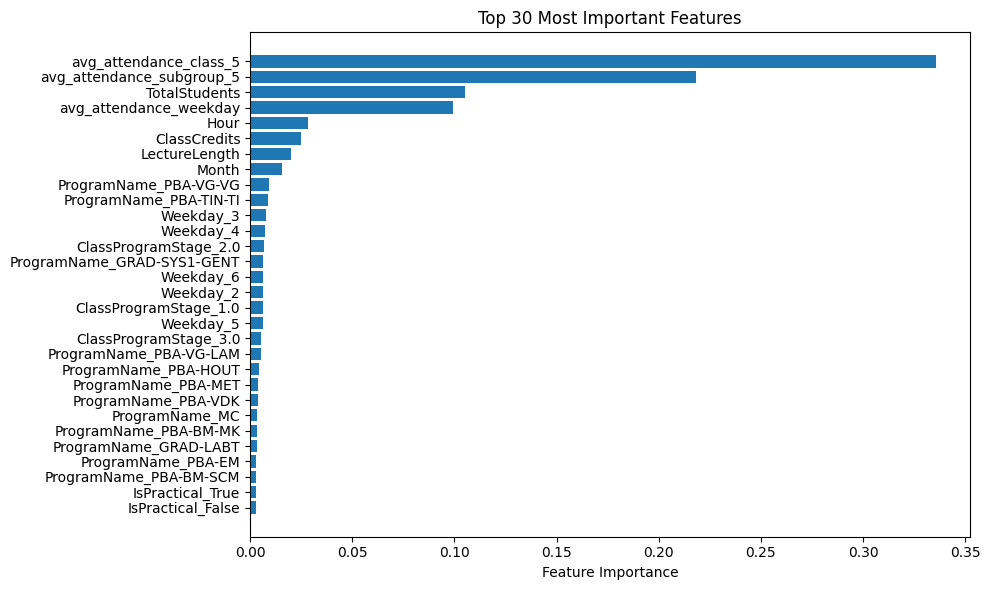

In [49]:
import matplotlib.pyplot as plt

top_n = 30
plt.figure(figsize=(10,6))
plt.barh(
    feature_importances["Feature"].iloc[:top_n][::-1],
    feature_importances["Importance"].iloc[:top_n][::-1],
    color="tab:blue"
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Most Important Features")
plt.tight_layout()
plt.show()
